# F1 Data Analysis
Cleans data and creates features for the ML model.

### Workflow
- Knowledge of dataset's structure
- Pattern identification
- Features Engineering
- Encoding for LSTM
- Remove and clean null/NaN values

### Requirements
- `f1_dataset_combined.pkl` (from DataLoader.ipynb)

### Output
| File | Descrizione |
|------|-------------|
| `f1_dataset_clean.pkl` | Clean dataset to training |
| `Analysis/` | Graphs |



# 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import os

In [2]:
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

df_f1 = pd.read_pickle('f1_dataset_combined.pkl')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.8 MB/s eta 0:00:00


In [3]:
def save_plot(fig, subfolder_name, filename):

    main_directory = 'Analysis'
    directory = os.path.join(main_directory, subfolder_name)

    if not os.path.exists(directory):
        os.makedirs(directory)

    file_path = os.path.join(directory, filename)
    fig.savefig(file_path, bbox_inches='tight')

    print(f"Plot saved to: {file_path}")

# 2. Cleaning & Norm

In [4]:
print(f"🔍 Data types:\n")
for col in df_f1.columns:
    print(f"{col:20}: {df_f1[col].dtype}")

🔍 Data types:

Time                : timedelta64[ns]
Driver              : object
DriverNumber        : object
LapTime             : timedelta64[ns]
LapNumber           : float64
Stint               : float64
PitOutTime          : timedelta64[ns]
PitInTime           : timedelta64[ns]
Sector1Time         : timedelta64[ns]
Sector2Time         : timedelta64[ns]
Sector3Time         : timedelta64[ns]
Sector1SessionTime  : timedelta64[ns]
Sector2SessionTime  : timedelta64[ns]
Sector3SessionTime  : timedelta64[ns]
SpeedI1             : float64
SpeedI2             : float64
SpeedFL             : float64
SpeedST             : float64
IsPersonalBest      : object
Compound            : object
TyreLife            : float64
FreshTyre           : bool
Team                : object
LapStartTime        : timedelta64[ns]
LapStartDate        : datetime64[ns]
TrackStatus         : object
Position            : float64
Deleted             : bool
DeletedReason       : object
FastF1Generated     : bool
IsAccu

## Conversions

In [5]:
# TIMEDELTA in sec
temporal_cols = ['LapTime', 'LapStartTime', 'Sector1Time',
                  'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                 'Sector2Time', 'Sector3Time', 'PitOutTime', 'PitInTime']

for col in temporal_cols:
    if col in df_f1.columns:
        new_col = f'{col}Sec'
        df_f1[new_col] = df_f1[col].dt.total_seconds()
        df_f1.drop(col, axis=1, inplace=True)

In [6]:
# TEAM name unification
print(f"\nTeam Before: {df_f1['Team'].unique()}")

team_mapping = {
    # RB / Racing Bulls / AlphaTauri -> Racing Bulls
    'RB': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',

    # Kick Sauber / Alfa Romeo -> Kick Sauber
    'Alfa Romeo': 'Kick Sauber'
}

df_f1['Team'] = df_f1['Team'].replace(team_mapping)

print(f"\nTeam After: {df_f1['Team'].unique()}")


Team Before: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'AlphaTauri'
 'Alpine' 'Williams' 'Alfa Romeo' 'Aston Martin' 'McLaren' 'RB'
 'Kick Sauber' 'Racing Bulls']

Team After: ['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


## Cleaning

In [7]:
# CLEANING INVALID COMPOUNDS
# Removes rows with 'None', 'nan' or NaN compounds
# These are incomplete data that would cause problems in training

valid_compounds = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

print(f"Compounds present before cleaning:")
print(df_f1['Compound'].value_counts(dropna=False))

# Count rows to remove
n_invalid = (df_f1['Compound'].isin(valid_compounds) == False).sum()

# Remove rows with invalid compounds
df_f1 = df_f1[df_f1['Compound'].isin(valid_compounds)]

print(f"\nRemoved {n_invalid:,} rows with invalid compounds")
print(f"\nCompounds present after cleaning:")
print(df_f1['Compound'].value_counts())

Compounds present before cleaning:
Compound
HARD            39678
MEDIUM          31907
SOFT            10397
INTERMEDIATE     4468
None              383
nan               382
WET               307
Name: count, dtype: int64

Removed 765 rows with invalid compounds

Compounds present after cleaning:
Compound
HARD            39678
MEDIUM          31907
SOFT            10397
INTERMEDIATE     4468
WET               307
Name: count, dtype: int64


In [8]:
# Since there are few occurrences, I replace "WET" with "INTERMEDIATE" rain tire
df_f1.loc[df_f1['Compound'] == 'WET', 'Compound'] = 'INTERMEDIATE'

## Null Values

In [9]:
# Count missing values
print("❓ Missing Values:")

missing = df_f1.isnull().sum()
missing_pct = (missing / len(df_f1) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}/{len(df_f1.columns)}\n")
print(missing_df.head(20))

❓ Missing Values:

Columns with missing values: 9/46

                       Missing  Percentage
PitOutTimeSec            86757      100.00
LapStartDate             86757      100.00
PitInTimeSec             86757      100.00
SpeedI1                  14777       17.03
SpeedST                   7064        8.14
SpeedI2                    782        0.90
Sector1SessionTimeSec      210        0.24
TyreLife                   183        0.21
SpeedFL                      4        0.00


In [10]:
cols_null = ['PitOutTimeSec', 'LapStartDate', 'PitInTimeSec']
for col in cols_null:
  if col in df_f1.columns:
    df_f1 = df_f1.drop(columns=cols_null)

In [11]:
seq_cols = ['SpeedI1','SpeedI2','SpeedST',
            'Humidity','TrackTemp','AirTemp',
            'WindSpeed','Rainfall','Pressure',
            'SpeedFL','Sector1TimeSec','TyreLife',
            'Sector1SessionTimeSec']


# Apply interpolation using transform for each column to ensure index alignment
for col in seq_cols:
  if col in df_f1.columns:
    df_f1[col] = df_f1.groupby(['Driver','Team'])[col].transform(lambda x: x.interpolate(method='linear'))

# Fill remaining NaNs at start/end of sequences with median
df_f1[seq_cols] = df_f1[seq_cols].fillna(df_f1[seq_cols].median())

# 3. Analisi dei Dati

In [12]:
# Data Types (present columns)
print(f"🔍 Data Types:\n")
for col in df_f1.columns:
    print(f"{col:30s}: {df_f1[col].dtype}")

🔍 Data Types:

Time                          : timedelta64[ns]
Driver                        : object
DriverNumber                  : object
LapNumber                     : float64
Stint                         : float64
SpeedI1                       : float64
SpeedI2                       : float64
SpeedFL                       : float64
SpeedST                       : float64
IsPersonalBest                : object
Compound                      : object
TyreLife                      : float64
FreshTyre                     : bool
Team                          : object
TrackStatus                   : object
Position                      : float64
Deleted                       : bool
DeletedReason                 : object
FastF1Generated               : bool
IsAccurate                    : bool
Year                          : int64
Round                         : int64
RaceName                      : object
Circuit                       : object
Country                       : object
Eve

In [13]:
# Overview
print(f"📦 Dataset Dimensions:")
print(f"   Rows (laps):         {len(df_f1):,}")
print(f"   Columns (features):  {len(df_f1.columns)}")

print(f"\n📅 Temporal Coverage:")
years = sorted(df_f1['Year'].unique())
print(f"   Years:               {years}")
for year in years:
    n_races = df_f1[df_f1['Year'] == year]['Round'].nunique()
    n_laps = len(df_f1[df_f1['Year'] == year])
    print(f"   {year}: {n_races:2d} races, {n_laps:,} laps")

print(f"\n🏁 Entities:")
print(f"   Total races:         {len(df_f1.groupby(['Year', 'Round']))}")
print(f"   Unique drivers:      {df_f1['Driver'].nunique()}")
print(f"   Unique teams:        {df_f1['Team'].nunique()}")
print(f"   Unique circuits:     {df_f1['Circuit'].nunique()}")

📦 Dataset Dimensions:
   Rows (laps):         86,757
   Columns (features):  43

📅 Temporal Coverage:
   Years:               [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
   2022: 22 races, 19,344 laps
   2023: 22 races, 21,248 laps
   2024: 24 races, 23,557 laps
   2025: 24 races, 22,608 laps

🏁 Entities:
   Total races:         92
   Unique drivers:      31
   Unique teams:        10
   Unique circuits:     26


## Metriche base

In [14]:
# Driver Distribution
print(df_f1["Driver"].unique())

['LEC' 'VER' 'SAI' 'HAM' 'MAG' 'PER' 'RUS' 'GAS' 'ALO' 'OCO' 'ALB' 'TSU'
 'MSC' 'BOT' 'HUL' 'STR' 'NOR' 'ZHO' 'LAT' 'RIC' 'VET' 'DEV' 'SAR' 'PIA'
 'LAW' 'BEA' 'COL' 'DOO' 'ANT' 'BOR' 'HAD']


In [15]:
# Team Distribution
print(df_f1["Team"].unique())

['Ferrari' 'Red Bull Racing' 'Mercedes' 'Haas F1 Team' 'Racing Bulls'
 'Alpine' 'Williams' 'Kick Sauber' 'Aston Martin' 'McLaren']


In [16]:
# Circuit Distribution
print(df_f1["Circuit"].unique())

['Sakhir' 'Jeddah' 'Melbourne' 'Imola' 'Miami' 'Barcelona' 'Monaco' 'Baku'
 'Montréal' 'Silverstone' 'Spielberg' 'Le Castellet' 'Budapest'
 'Spa-Francorchamps' 'Zandvoort' 'Monza' 'Marina Bay' 'Suzuka' 'Austin'
 'Mexico City' 'São Paulo' 'Yas Island' 'Lusail' 'Las Vegas' 'Shanghai'
 'Miami Gardens']


In [17]:
# Pirelli Tire Distribution
print(df_f1["Compound"].unique())

['SOFT' 'MEDIUM' 'HARD' 'INTERMEDIATE']


In [18]:
# LapTime Statistics
print(f"Lap Time Statistics:\n")
if 'LapTimeSec' in df_f1.columns:
    # Filter outliers (< 60s or > 200s are pit lane / safety car)
    valid_laps = df_f1[(df_f1['LapTimeSec'] > 60) & (df_f1['LapTimeSec'] < 200)]

    print(f"   Total laps:          {len(df_f1):,}")
    print(f"   Valid laps:          {len(valid_laps):,} ({len(valid_laps)/len(df_f1)*100:.1f}%)")
    print(f"   Min:                 {valid_laps['LapTimeSec'].min():.2f}s")
    print(f"   Max:                 {valid_laps['LapTimeSec'].max():.2f}s")
    print(f"   Average:             {valid_laps['LapTimeSec'].mean():.2f}s")
    print(f"   Median:              {valid_laps['LapTimeSec'].median():.2f}s")
    print(f"   Std Dev:             {valid_laps['LapTimeSec'].std():.2f}s")

Lap Time Statistics:

   Total laps:          86,757
   Valid laps:          86,757 (100.0%)
   Min:                 67.01s
   Max:                 149.32s
   Average:             89.09s
   Median:              87.38s
   Std Dev:             10.93s


In [19]:
df_f1['UnderCaution'] = (df_f1['SafetyCarStatus'] == 'SC').astype(int)

n_sc_laps = df_f1['UnderCaution'].sum()
total_laps = len(df_f1)
percentage_sc = (n_sc_laps / total_laps) * 100
print(f"   Laps under SC:   {n_sc_laps:,} ({percentage_sc:.2f}%)")

   Laps under SC:   17,502 (20.17%)


In [20]:
# Speed Traps Analysis

print("📊 SPEED TRAPS STATISTICS")
print("=" * 60)

speed_cols = ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

for col in speed_cols:
    if col in df_f1.columns:
        valid = df_f1[col].notna().sum()
        pct = valid / len(df_f1) * 100
        print(f"\n{col}:")
        print(f"   Valid values: {valid:,} ({pct:.1f}%)")
        print(f"   Min: {df_f1[col].min():.1f} km/h")
        print(f"   Max: {df_f1[col].max():.1f} km/h")
        print(f"   Average: {df_f1[col].mean():.1f} km/h")
        print(f"   Std: {df_f1[col].std():.1f} km/h")

📊 SPEED TRAPS STATISTICS

SpeedI1:
   Valid values: 86,757 (100.0%)
   Min: 60.0 km/h
   Max: 357.0 km/h
   Average: 259.0 km/h
   Std: 43.8 km/h

SpeedI2:
   Valid values: 86,757 (100.0%)
   Min: 79.0 km/h
   Max: 344.0 km/h
   Average: 251.8 km/h
   Std: 41.5 km/h

SpeedFL:
   Valid values: 86,757 (100.0%)
   Min: 69.0 km/h
   Max: 359.0 km/h
   Average: 269.0 km/h
   Std: 32.5 km/h

SpeedST:
   Valid values: 86,757 (100.0%)
   Min: 100.0 km/h
   Max: 364.0 km/h
   Average: 302.8 km/h
   Std: 18.4 km/h


## Metriche Approfondite

### Analisi Piloti

Plot saved to: Analysis/DriverAnalysis/driver_rank_laps


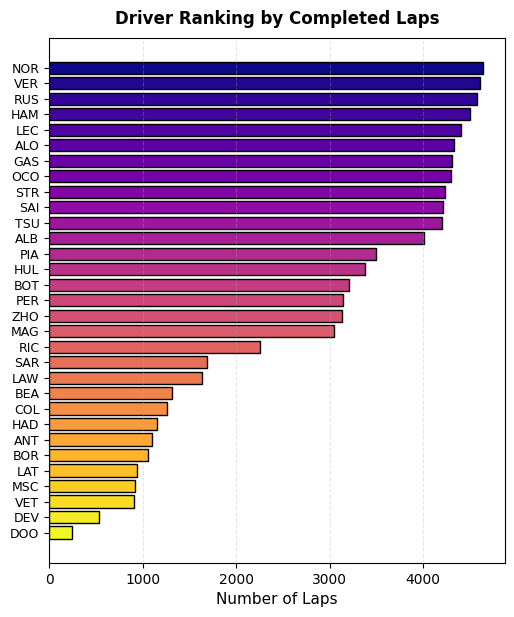

In [21]:
# Driver Ranking by Completed Laps

fig = plt.figure(figsize=(20, 15))
ax = plt.subplot(2, 3, 1)
top_drivers = df_f1['Driver'].value_counts()
colors = plt.cm.plasma(np.linspace(0, 1, len(top_drivers)))
bars = ax.barh(range(len(top_drivers)), top_drivers.values, color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top_drivers)))
ax.set_yticklabels(top_drivers.index, fontsize=9)
ax.set_xlabel('Number of Laps', fontsize=11)
ax.set_title('Driver Ranking by Completed Laps', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_rank_laps")

Plot saved to: Analysis/DriverAnalysis/driver_position_distribution


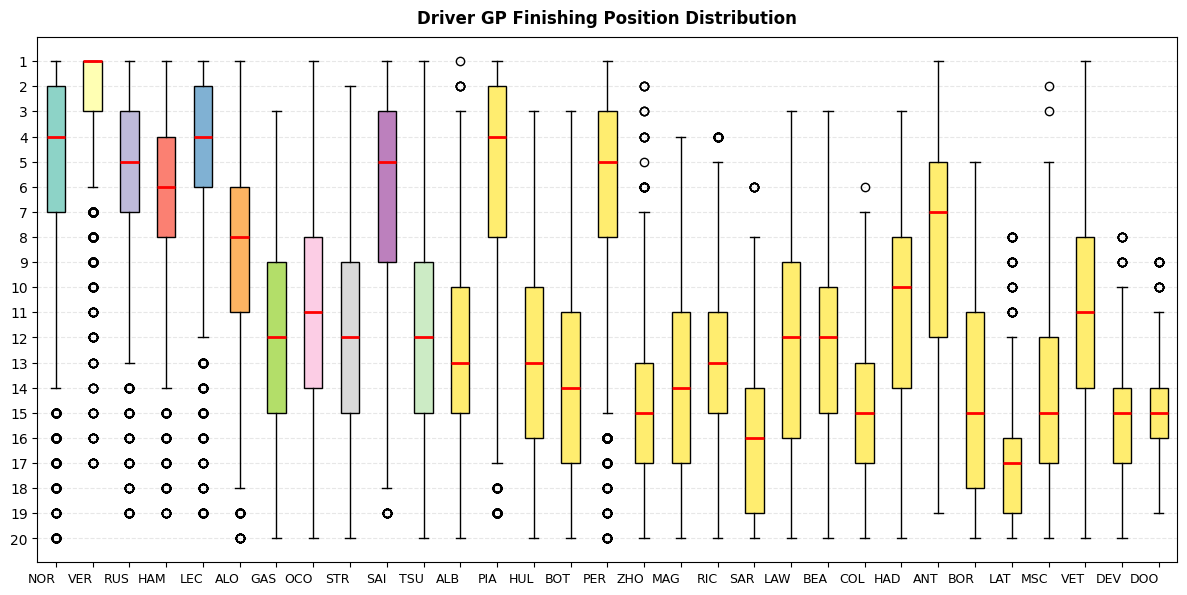

In [22]:
# Driver Position Distribution

fig = plt.figure(figsize=(50, 15))
ax = plt.subplot(2, 3, 3)
top_drivers = df_f1['Driver'].value_counts().index
data_to_plot = [df_f1[df_f1['Driver'] == driver]['Position'].dropna().values
                for driver in top_drivers]
bp = ax.boxplot(data_to_plot, labels=top_drivers, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_drivers)))):
    patch.set_facecolor(color)
ax.set_xticklabels(top_drivers, ha='right', fontsize=9)
ax.set_yticks(range(1, 21))
ax.set_title('Driver GP Finishing Position Distribution', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_position_distribution")

Plot saved to: Analysis/DriverAnalysis/driver_avg_position


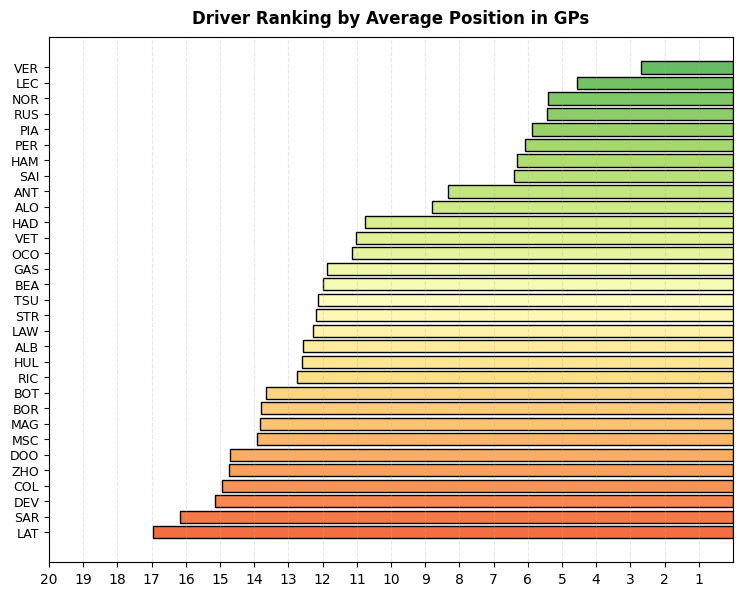

In [23]:
# Driver Average Position Distributions

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 5)
avg_position = df_f1.groupby('Driver')['Position'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(avg_position)))
bars = ax.barh(range(len(avg_position)), avg_position.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(avg_position)))
ax.set_yticklabels(avg_position.index, fontsize=9)
ax.set_xticks(range(1, 21))
ax.set_title('Driver Ranking by Average Position in GPs', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.invert_xaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "DriverAnalysis", "driver_avg_position")

Plot saved to: Analysis/DriverAnalysis/driver_participation_years


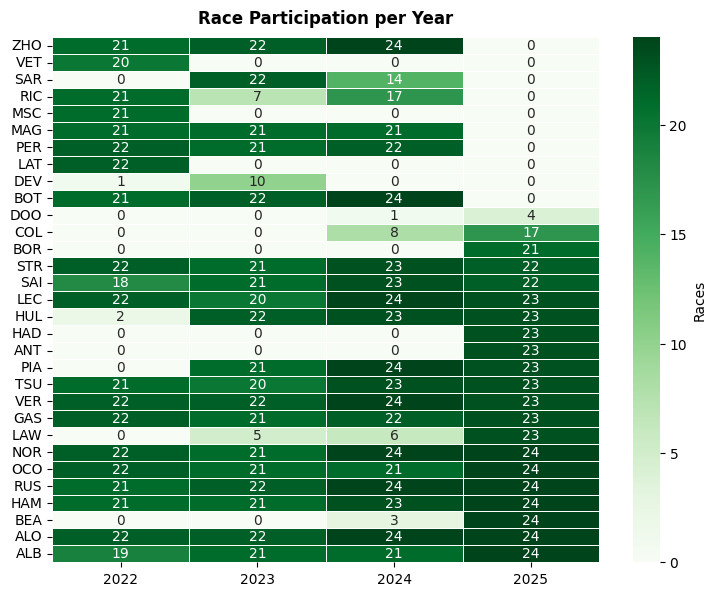

In [24]:
# Driver Participation in Races per Year

fig = plt.figure(figsize=(30, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Race Participation per Year', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Driver'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Driver', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Races'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "DriverAnalysis", "driver_participation_years")

### Analisi Team

Plot saved to: Analysis/TeamAnalysis/team_rank_laps


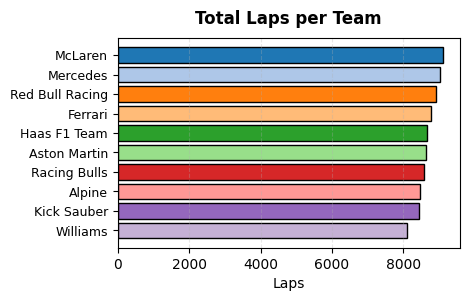

In [25]:
# Team Ranking by Completed Laps

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 3)
team_totals = df_f1['Team'].value_counts()
colors = plt.cm.tab20(range(len(team_totals)))
bars = ax.barh(range(len(team_totals)), team_totals.values, color=colors,
                edgecolor='black', linewidth=1)
ax.set_yticks(range(len(team_totals)))
ax.set_yticklabels(team_totals.index, fontsize=9)
ax.set_xlabel('Laps')
ax.set_title('Total Laps per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_rank_laps")

Plot saved to: Analysis/TeamAnalysis/team_participation_years


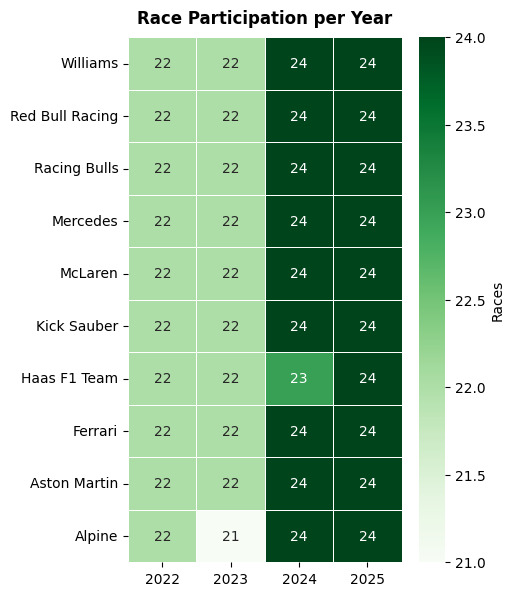

In [26]:
# Driver Participation in Races per Year

fig = plt.figure(figsize=(15, 15))
ax = plt.subplot(2, 3, 4)
ax.set_title('Race Participation per Year', fontsize=12, fontweight='bold', pad=10)
participation = df_f1.groupby(['Year', 'Team'])['Round'].nunique().reset_index()
participation_pivot = participation.pivot(index='Team', columns='Year', values='Round').fillna(0)
participation_pivot = participation_pivot[participation_pivot.sum(axis=1) > 1].sort_values(
    by=participation_pivot.columns[-1], ascending=False)
sns.heatmap(participation_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax,
           linewidths=0.5, cbar_kws={'label': 'Races'})
ax.set_xlabel('', fontsize=11, fontweight='bold')
ax.set_ylabel('', fontsize=11, fontweight='bold')
ax.invert_yaxis()

save_plot(fig, "TeamAnalysis", "team_participation_years")

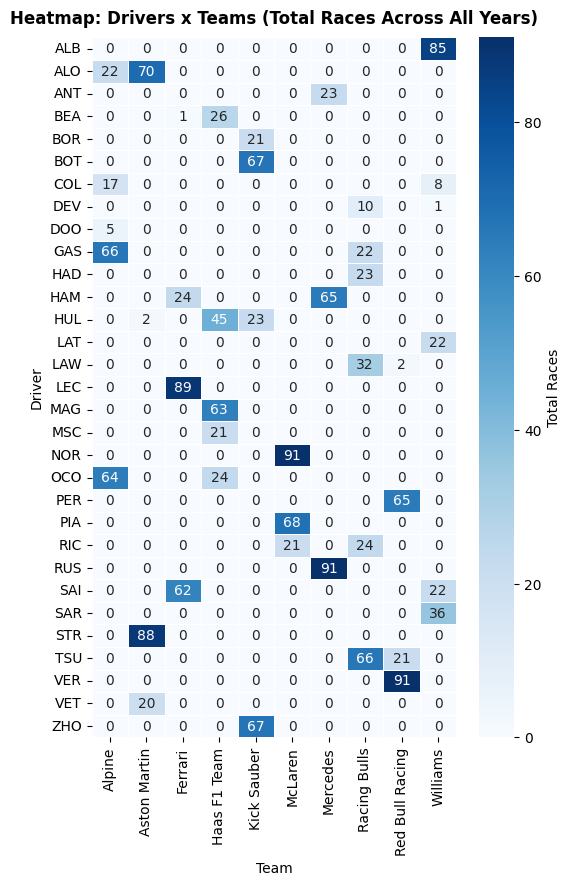

Plot saved to: Analysis/TeamAnalysis/team_participation_drivers


In [27]:
# Driver Participation in Races per Team

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(2, 3, 4)
top_drivers = df_f1['Driver'].value_counts().index
pivot_driver_team = df_f1[df_f1['Driver'].isin(top_drivers)].pivot_table(
    values='Round',
    index=['Driver', 'Year'],
    columns='Team',
    aggfunc='nunique',
    fill_value=0
)
pivot_driver_team_total = pivot_driver_team.groupby(level='Driver').sum()
sns.heatmap(pivot_driver_team_total, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Total Races'})
ax.set_title('Heatmap: Drivers x Teams (Total Races Across All Years)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "TeamAnalysis", "team_participation_drivers")

Plot saved to: Analysis/TeamAnalysis/team_position_distribution


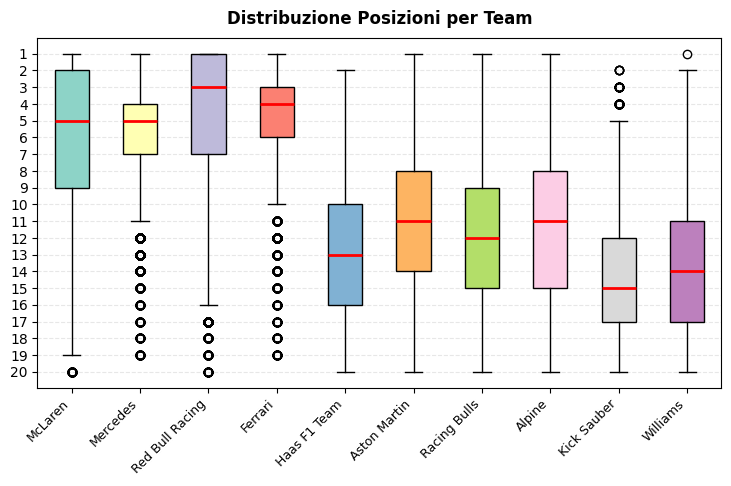

In [28]:
# Distribuzione delle Posizione nei GP per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)
top_teams = df_f1['Team'].value_counts().index
data_to_plot = [df_f1[df_f1['Team'] == team]['Position'].dropna().values
                for team in top_teams]
bp = ax.boxplot(data_to_plot, labels=top_teams, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(top_teams)))):
    patch.set_facecolor(color)
ax.set_yticks(range(1, 21))
ax.set_xticklabels(top_teams, rotation=45, ha='right', fontsize=9)
ax.set_title('Distribuzione Posizioni per Team', fontsize=12, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')

save_plot(fig, "TeamAnalysis", "team_position_distribution")

### Analisi Gomme

Plot saved to: Analysis/CompoundAnalysis/compound_distribution


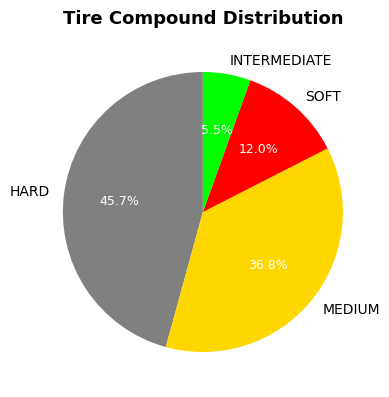

In [29]:
# Compound Distribution Used
fig = plt.figure(figsize=(30, 10))

ax = plt.subplot(2, 3, 4)
compound_colors = {
    'HARD': '#808080', 'WET': '#0000FF', 'MEDIUM': '#FFD700', 'SOFT': '#FF0000',
    'INTERMEDIATE': '#00FF00'}

compound_data = df_f1['Compound'].value_counts().dropna()
compound_data = compound_data[compound_data.index.isin(compound_colors.keys())]
colors = [compound_colors.get(c, '#CCCCCC') for c in compound_data.index]
wedges, texts, autotexts = ax.pie(compound_data.values, labels=compound_data.index,
                                    autopct='%1.1f%%', startangle=90, colors=colors,
                                    )
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
ax.set_title('Tire Compound Distribution', fontsize=13, fontweight='bold', pad=10)

save_plot(fig, "CompoundAnalysis", "compound_distribution")

Plot saved to: Analysis/CompoundAnalysis/compound_true_degradation


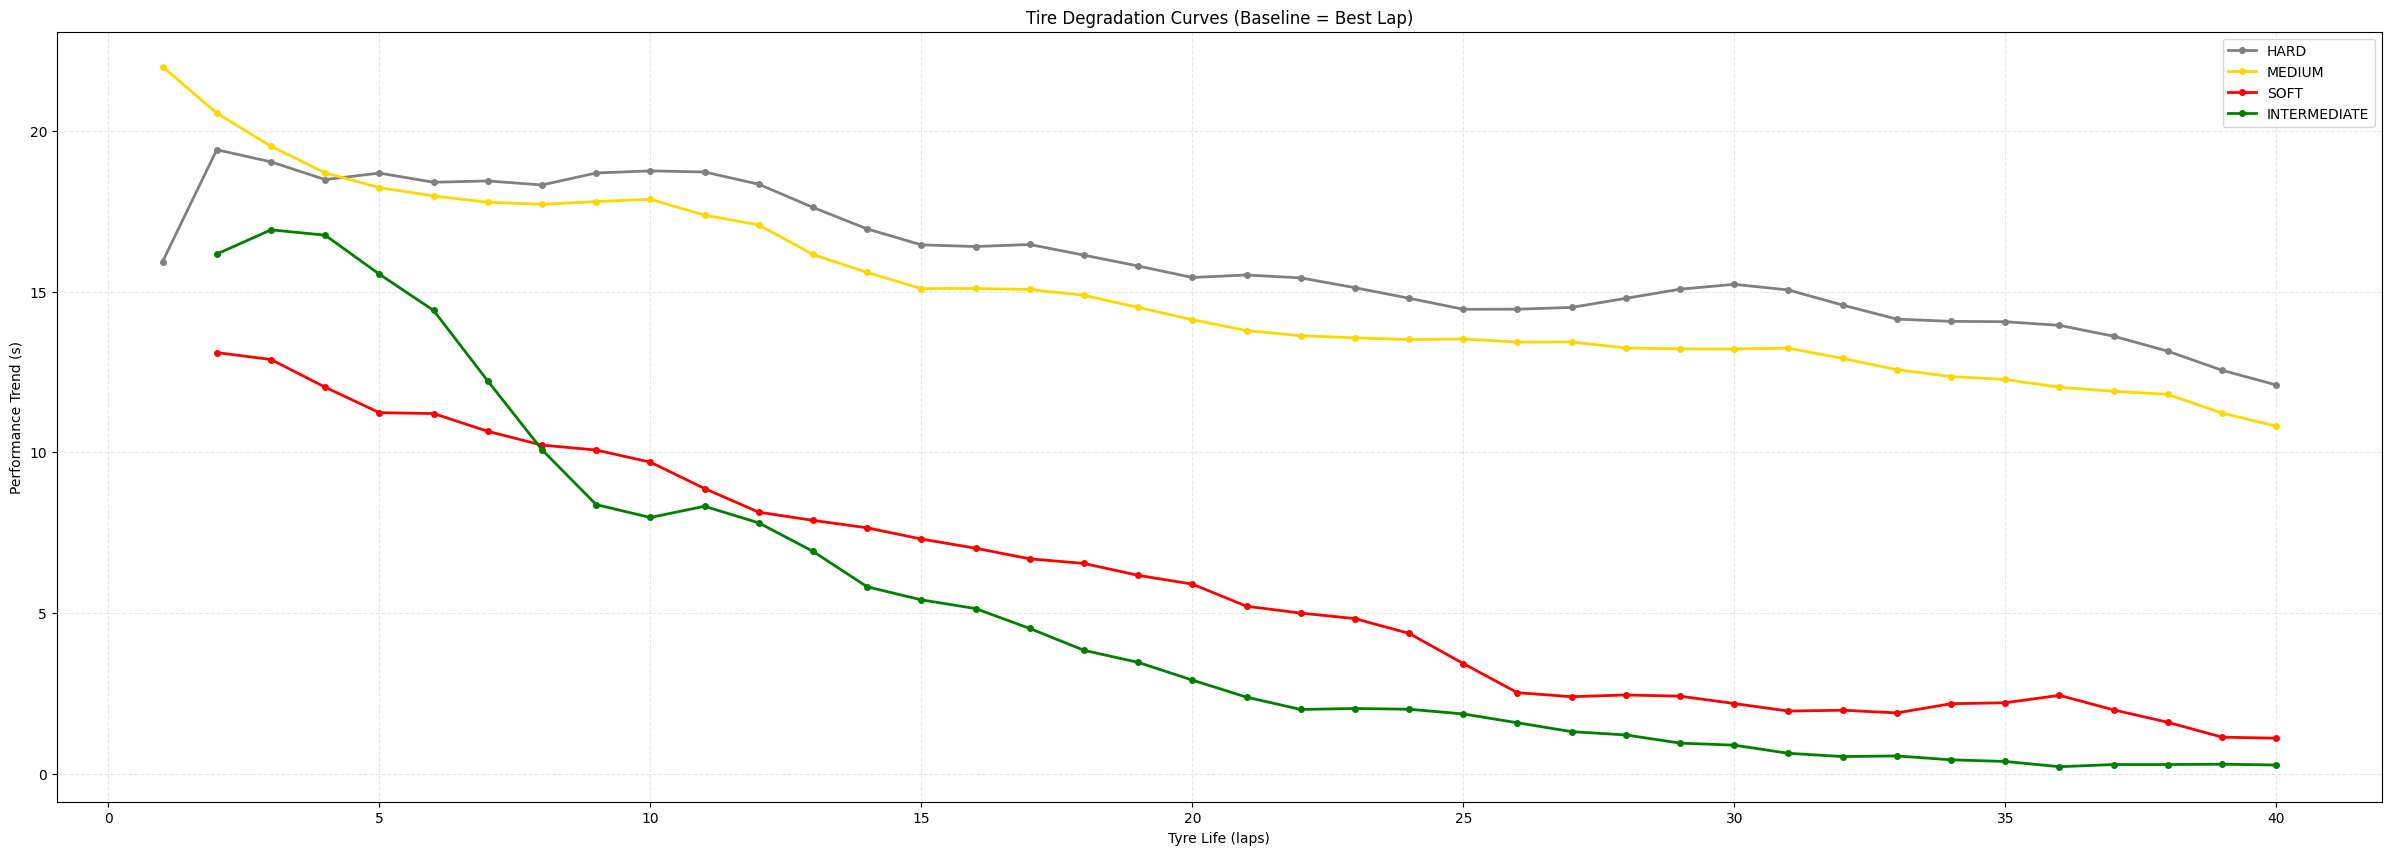

In [30]:
# True Tyre Degradation
fig, ax = plt.subplots(figsize=(30, 10), nrows=1, ncols=1)

required_cols = {'LapTimeSec', 'TyreLife', 'Compound', 'SafetyCarStatus', 'Driver', 'Stint'}

if required_cols.issubset(df_f1.columns):
    for compound, color in [('HARD', 'grey'), ('MEDIUM', 'gold'), ('SOFT', 'red'), ('INTERMEDIATE', 'green')]:
        data = df_f1.query(
            "Compound == @compound and TyreLife <= 40 and SafetyCarStatus != 'SC'"
        ).copy()

        if data.empty:
            continue

        data['TyreLifeInt'] = data['TyreLife'].astype(int)
        data['Degradation'] = data['LapTimeSec'] - data.groupby(['Driver', 'Stint'])['LapTimeSec'].transform('min')

        raw = data.groupby('TyreLifeInt')['Degradation'].median().sort_index()
        smoothed = raw.rolling(window=3, center=True, min_periods=1).mean()
        raw[raw.index >= 6] = smoothed[raw.index >= 6]

        ax.plot(raw.index, raw.values, marker='o', label=compound, color=color, linewidth=2, markersize=4)

    ax.set(xlabel='Tyre Life (laps)', ylabel='Performance Trend (s)',
           title='Tire Degradation Curves (Baseline = Best Lap)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_true_degradation")

Plot saved to: Analysis/CompoundAnalysis/compound_tyrelife_distribution


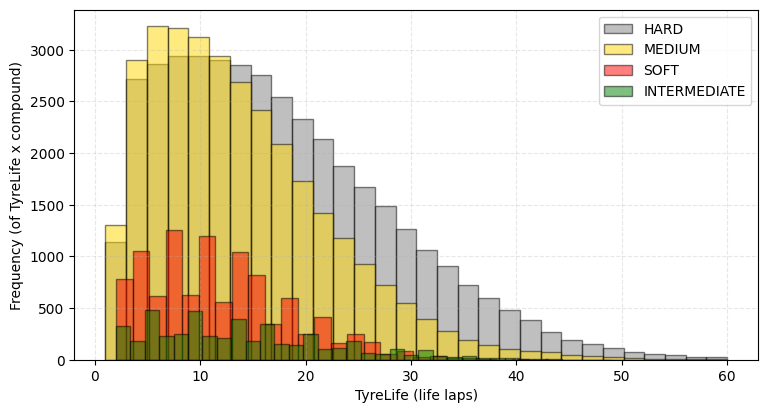

In [31]:
# Frequency of Laps Completed for each Compound

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 4)
if 'TyreLife' in df_f1.columns:
    for compound, color in [ ('HARD', 'grey'), ('MEDIUM', 'gold'), ('SOFT', 'red'), ('INTERMEDIATE', 'green')]:
        compound_tyrelife = df_f1[df_f1['Compound'] == compound]['TyreLife'].dropna()
        compound_tyrelife = compound_tyrelife[compound_tyrelife <= 60]
        ax.hist(compound_tyrelife, bins=30, alpha=0.5, label=compound,
                color=color, edgecolor='black')
    ax.set_xlabel('TyreLife (life laps)')
    ax.set_ylabel('Frequency (of TyreLife x compound)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "CompoundAnalysis", "compound_tyrelife_distribution")

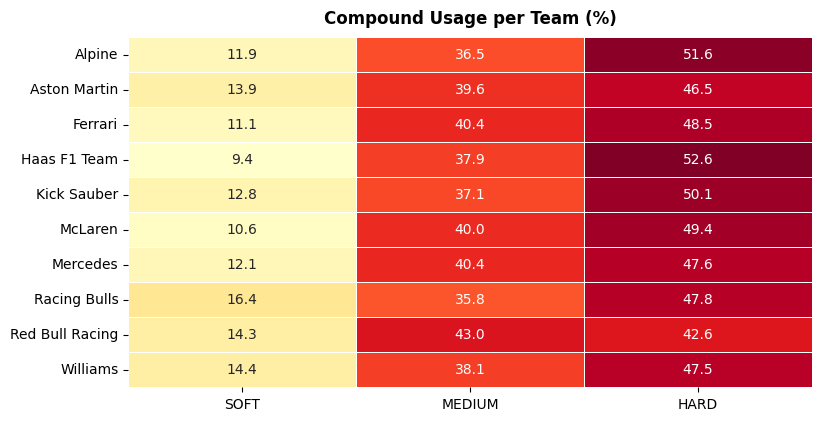

Plot saved to: Analysis/CompoundAnalysis/compound_usage_team


In [32]:
# Tire Used per Team

fig = plt.figure(figsize=(30, 10))
ax = plt.subplot(2, 3, 5)

top_teams = df_f1['Team'].value_counts().index
compound_usage = df_f1[df_f1['Team'].isin(top_teams)].pivot_table(
    values='LapNumber', index='Team', columns='Compound', aggfunc='count', fill_value=0
)
for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]

compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Compound Usage per Team (%)', fontsize=12, fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CompoundAnalysis", "compound_usage_team")

### Analisi Meteo

Plot saved to: Analysis/WeatherAnalysis/weather_distribution


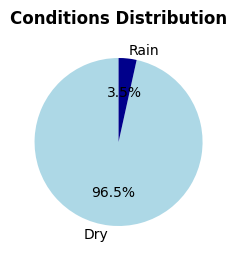

In [33]:
# Rain or Dry

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(2, 3, 6)
if 'Rainfall' in df_f1.columns:
    rainfall_counts = df_f1['Rainfall'].value_counts()
    colors_rain = ['lightblue', 'darkblue']
    ax.pie(rainfall_counts.values, labels=['Dry', 'Rain'],
           autopct='%1.1f%%', startangle=90, colors=colors_rain)
    ax.set_title('Conditions Distribution', fontsize=12, fontweight='bold', pad=10)

    save_plot(fig, "WeatherAnalysis", "weather_distribution")

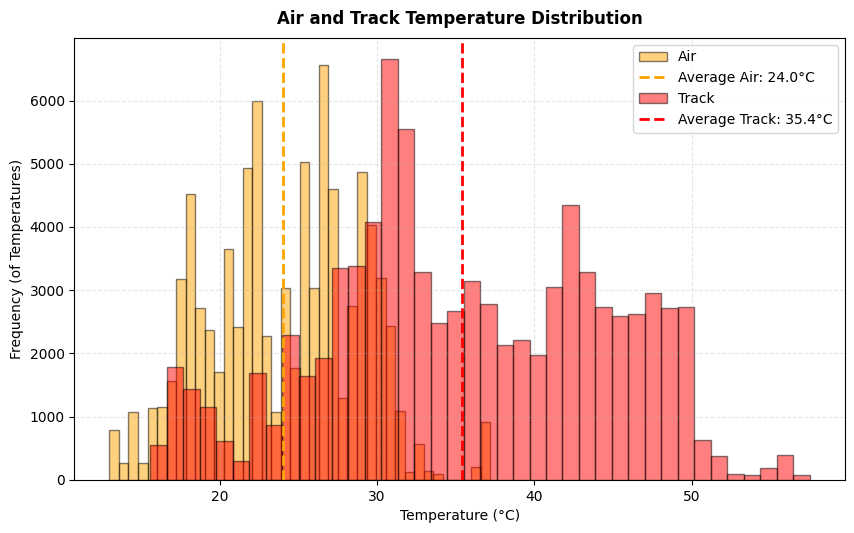

Plot saved to: Analysis/WeatherAnalysis/weather_temperature


In [34]:
# Air and Track Temperature

fig = plt.figure(figsize=(25, 10))
ax = plt.subplot(2, 3, 3)

if 'AirTemp' in df_f1.columns:
    ax.hist(df_f1['AirTemp'], bins=40, edgecolor='black', alpha=0.5, color='orange', label='Air')
    mean_temp = df_f1['AirTemp'].mean()
    ax.axvline(mean_temp, color='orange', linestyle='--', linewidth=2,
               label=f'Average Air: {mean_temp:.1f}°C')

if 'TrackTemp' in df_f1.columns:
    ax.hist(df_f1['TrackTemp'], bins=40, edgecolor='black', alpha=0.5, color='red', label='Track')
    mean_track = df_f1['TrackTemp'].mean()
    ax.axvline(mean_track, color='red', linestyle='--', linewidth=2,
               label=f'Average Track: {mean_track:.1f}°C')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency (of Temperatures)')
ax.set_title('Air and Track Temperature Distribution', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

save_plot(fig, "WeatherAnalysis", "weather_temperature")

Plot saved to: Analysis/WeatherAnalysis/weather_windspeed


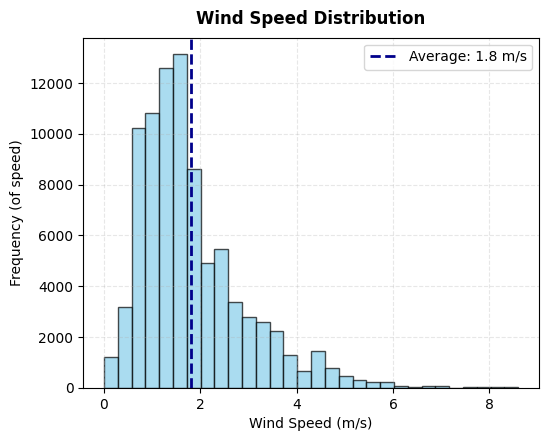

In [35]:
# Wind Speed

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(2, 3, 5)
if 'WindSpeed' in df_f1.columns:
    ax.hist(df_f1['WindSpeed'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    mean_wind = df_f1['WindSpeed'].mean()
    ax.axvline(mean_wind, color='darkblue', linestyle='--', linewidth=2,
               label=f'Average: {mean_wind:.1f} m/s')
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Frequency (of speed)')
    ax.set_title('Wind Speed Distribution', fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

    save_plot(fig, "WeatherAnalysis", "weather_windspeed")

### Analisi Circuiti

Plot saved to: Analysis/CircuitAnalysis/circuit_laptime


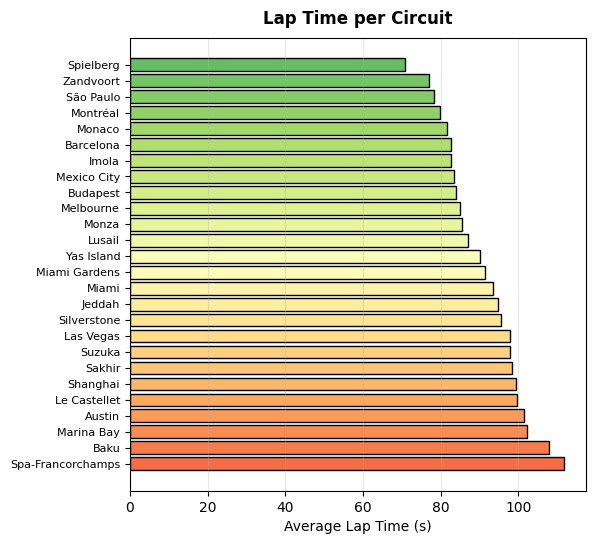

In [36]:
# Average Lap Time per Circuit

fig = plt.figure(figsize=(20, 20))
ax = plt.subplot(3, 3, 2)
top_circuits = df_f1['Circuit'].value_counts().index
circuit_laptimes = valid_laps[valid_laps['Circuit'].isin(top_circuits)].groupby('Circuit')['LapTimeSec'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(circuit_laptimes)))
ax.barh(range(len(circuit_laptimes)), circuit_laptimes.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_laptimes)))
ax.set_yticklabels(circuit_laptimes.index, fontsize=8)
ax.set_xlabel('Average Lap Time (s)')
ax.set_title('Lap Time per Circuit', fontweight='bold', pad=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_laptime")

Plot saved to: Analysis/CircuitAnalysis/circuit_count


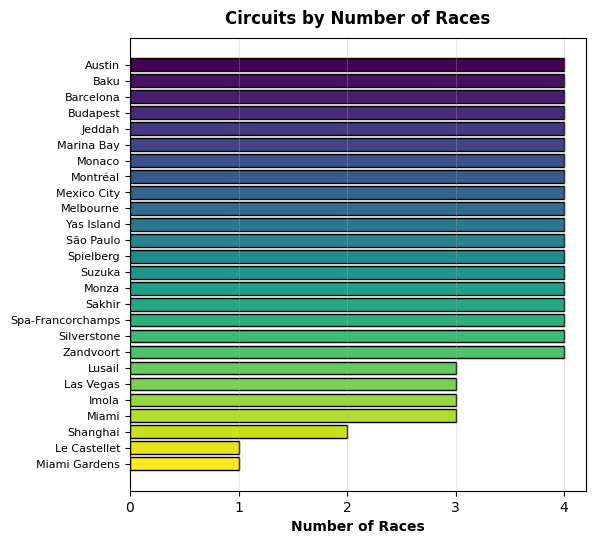

In [37]:
# Races per Circuit over 4 years
fig = plt.figure(figsize=(20, 20))

ax = plt.subplot(3, 3, 1)
circuit_counts = df_f1.groupby('Circuit').apply(lambda x: x[['Year','Round']].drop_duplicates().shape[0]).sort_values(ascending=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(circuit_counts)))

ax.barh(range(len(circuit_counts)), circuit_counts.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(circuit_counts)))
ax.set_yticklabels(circuit_counts.index, fontsize=8)
ax.set_xlabel('Number of Races', fontweight='bold')
ax.set_title('Circuits by Number of Races', fontweight='bold', pad=10)
ax.set_xticks(range(0, circuit_counts.max() + 1))

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_count")

Plot saved to: Analysis/CircuitAnalysis/circuit_temp


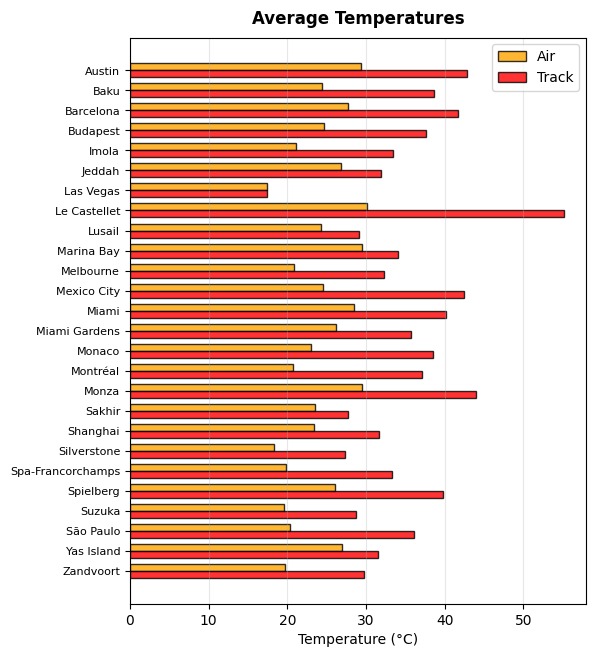

In [38]:
# Average Temperature per Circuit
fig = plt.figure(figsize=(20, 25))

ax = plt.subplot(3, 3, 4)
circuit_temp = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['AirTemp', 'TrackTemp']].mean()
x = np.arange(len(circuit_temp))
width = 0.35
ax.barh(x - width/2, circuit_temp['AirTemp'], width, label='Air', color='orange', alpha=0.8, edgecolor='black')
ax.barh(x + width/2, circuit_temp['TrackTemp'], width, label='Track', color='red', alpha=0.8, edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(circuit_temp.index, fontsize=8)
ax.set_xlabel('Temperature (°C)')
ax.set_title('Average Temperatures', fontweight='bold', pad=10)
ax.legend()
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_temp")

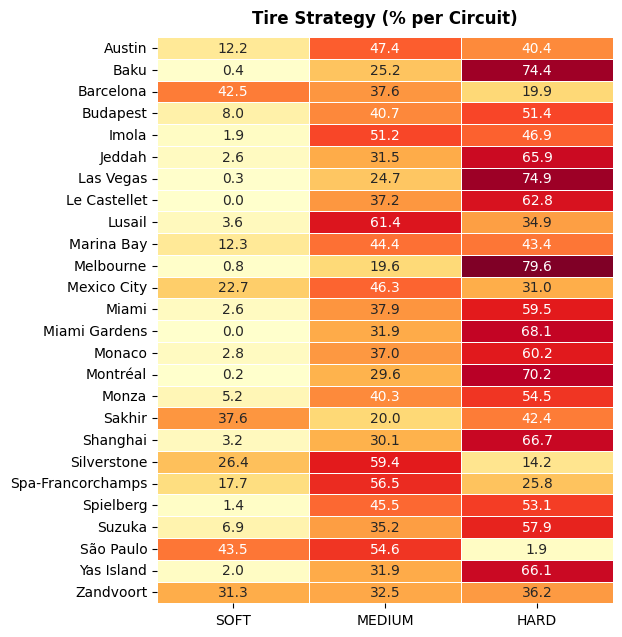

Plot saved to: Analysis/CircuitAnalysis/circuit_compound_usage


In [39]:
# Tire Strategy per Circuit (in % for various years)

fig = plt.figure(figsize=(20, 25))
ax = plt.subplot(3, 3, 6)

top_circuits = df_f1['Circuit'].value_counts().index
compound_usage = df_f1[df_f1['Circuit'].isin(top_circuits)].pivot_table(
    values='LapNumber', index='Circuit', columns='Compound', aggfunc='count', fill_value=0
)

for col in ['SOFT','MEDIUM','HARD']:
    if col not in compound_usage.columns:
        compound_usage[col] = 0
compound_usage = compound_usage[['SOFT','MEDIUM','HARD']]
compound_percentage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100
sns.heatmap(compound_percentage, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar=False)
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title('Tire Strategy (% per Circuit)', fontweight='bold', pad=10)
plt.show()

save_plot(fig, "CircuitAnalysis", "circuit_compound_usage")

Plot saved to: Analysis/CircuitAnalysis/circuit_weather


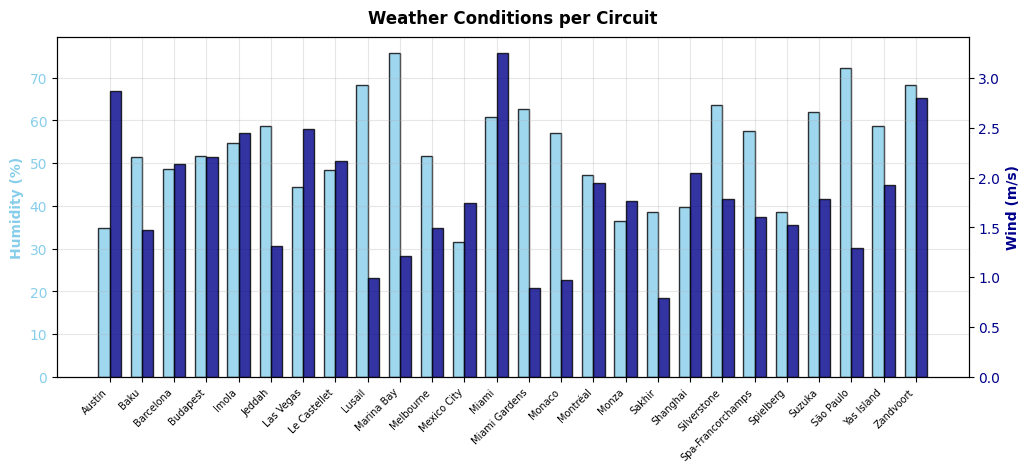

In [40]:
# Humidity and Wind per Circuit
fig = plt.figure(figsize=(40, 15))

ax = plt.subplot(3, 3, 8)
circuit_weather = df_f1[df_f1['Circuit'].isin(top_circuits)].groupby('Circuit')[['Humidity', 'WindSpeed']].mean()
x = np.arange(len(circuit_weather))
ax_twin = ax.twinx()
ax.bar(x - width/2, circuit_weather['Humidity'], width, label='Humidity', color='skyblue', alpha=0.8, edgecolor='black')
ax_twin.bar(x + width/2, circuit_weather['WindSpeed'], width, label='Wind', color='darkblue', alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(circuit_weather.index, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Humidity (%)', fontweight='bold', color='skyblue')
ax_twin.set_ylabel('Wind (m/s)', fontweight='bold', color='darkblue')
ax.set_title('Weather Conditions per Circuit', fontweight='bold', pad=10)
ax.tick_params(axis='y', labelcolor='skyblue')
ax_twin.tick_params(axis='y', labelcolor='darkblue')
ax.grid(alpha=0.3)

save_plot(fig, "CircuitAnalysis", "circuit_weather")

### Analisi Gara

Plot saved to: Analysis/SafetyCarAnalysis/safety_car_status


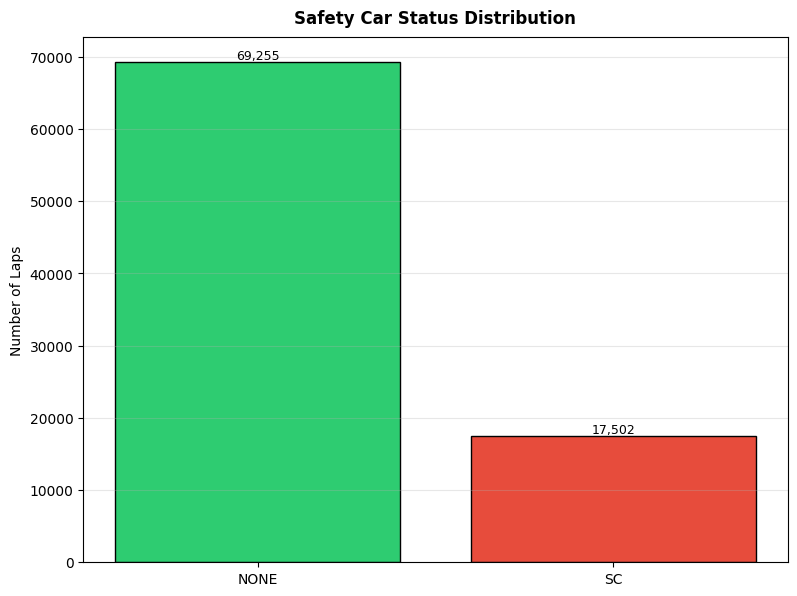

In [41]:
# SC/VSC Distribution
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1)
if 'SafetyCarStatus' in df_f1.columns:
    sc_counts = df_f1['SafetyCarStatus'].value_counts()
    colors = {'NONE': '#2ecc71', 'SC': '#e74c3c', 'VSC': '#f39c12'}
    bar_colors = [colors.get(x, '#95a5a6') for x in sc_counts.index]
    bars = ax.bar(sc_counts.index, sc_counts.values, color=bar_colors, edgecolor='black')
    ax.set_ylabel('Number of Laps')
    ax.set_title('Safety Car Status Distribution', fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, sc_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

save_plot(fig, "SafetyCarAnalysis", "safety_car_status")

Plot saved to: Analysis/SafetyCarAnalysis/safety_car_by_circuit


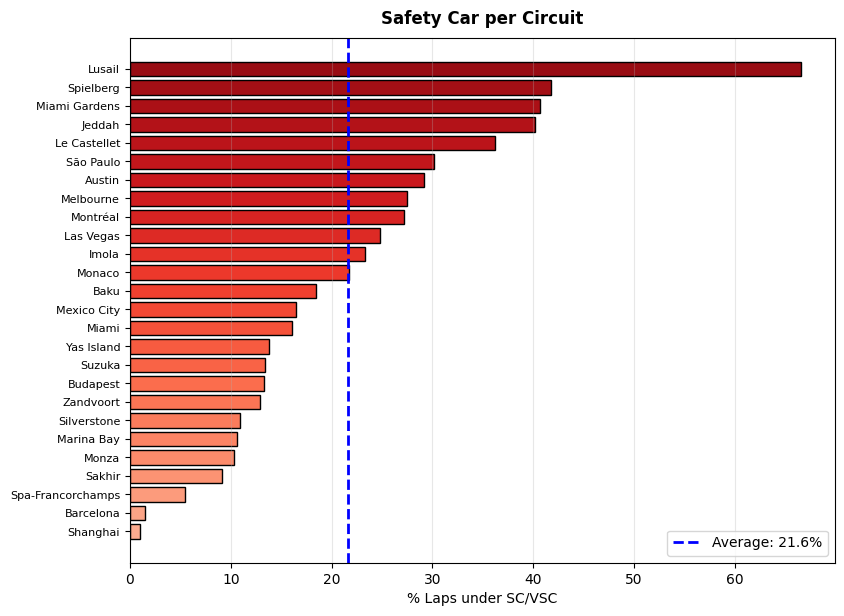

In [42]:
# % SC/VSC for Circuit
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 2)

caution_by_circuit = df_f1.groupby('Circuit')['UnderCaution'].mean().sort_values() * 100
colors2 = plt.cm.Reds(np.linspace(0.3, 0.9, len(caution_by_circuit)))
ax.barh(range(len(caution_by_circuit)), caution_by_circuit.values, color=colors2, edgecolor='black')
ax.set_yticks(range(len(caution_by_circuit)))
ax.set_yticklabels(caution_by_circuit.index, fontsize=8)
ax.set_xlabel('% Laps under SC/VSC')
ax.set_title('Safety Car per Circuit', fontweight='bold', pad=10)
ax.grid(axis='x', alpha=0.3)
mean_caution = caution_by_circuit.mean()
ax.axvline(mean_caution, color='blue', linestyle='--', linewidth=2, label=f'Average: {mean_caution:.1f}%')
ax.legend(loc='lower right')

save_plot(fig, "SafetyCarAnalysis", "safety_car_by_circuit")

Plot saved to: Analysis/SafetyCarAnalysis/safety_car_by_season


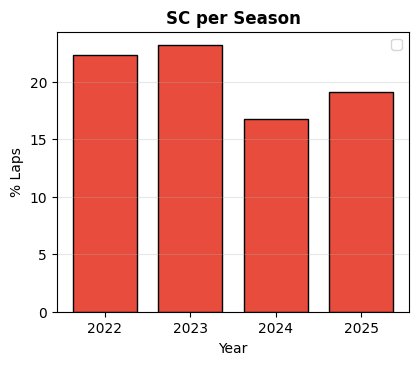

In [43]:
# % SC/VSC for Year

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(2, 2, 3)

if 'UnderCaution' in df_f1.columns and df_f1['UnderCaution'].sum() > 0:
    # Percentage of laps under SC per year
    sc_by_year = df_f1.groupby('Year')['UnderCaution'].mean() * 100

    x = np.arange(len(sc_by_year))
    width = 0.75

    ax.bar(x, sc_by_year, width, color='#e74c3c', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(sc_by_year.index.astype(str))
    ax.set_xlabel('Year')
    ax.set_ylabel('% Laps')
    ax.set_title('SC per Season', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

save_plot(fig, "SafetyCarAnalysis", "safety_car_by_season")

# 4. Label Encoding

## Data

### Tyre

In [44]:
df_f1['IsSoft'] = (df_f1['Compound'] == 'SOFT').astype(int)
df_f1['IsMedium'] = (df_f1['Compound'] == 'MEDIUM').astype(int)
df_f1['IsHard'] = (df_f1['Compound'] == 'HARD').astype(int)
df_f1['IsInter'] = (df_f1['Compound'] == 'INTERMEDIATE').astype(int)
df_f1['IsWet'] = (df_f1['Compound'] == 'WET').astype(int)

In [45]:
df_f1['FreshTyre'] = df_f1['FreshTyre'].astype(int) if 'FreshTyre' in df_f1.columns else 0

### Weather

In [46]:
df_f1['Rainfall'] = df_f1['Rainfall'].astype(int) if 'Rainfall' in df_f1.columns else 0

### Lap

In [47]:
df_f1['IsPersonalBest'] = df_f1['IsPersonalBest'].map({'True':1, 'False':0}).fillna(0).astype(int)

### Circuit
For each circuit in the year I encode the "object" in 2 values:
- undercut probability
- overcut probability

In [48]:
CIRCUIT_STRATEGY_SCORES = {
    'Sakhir':            [0.45, 0.55],
    'Jeddah':            [0.55, 0.45],
    'Melbourne':         [0.40, 0.60],
    'Imola':             [0.65, 0.35],
    'Miami':             [0.50, 0.50],
    'Barcelona':         [0.65, 0.35],
    'Monaco':            [0.90, 0.10],
    'Baku':              [0.60, 0.40],
    'Montréal':          [0.50, 0.50],
    'Silverstone':       [0.30, 0.70],
    'Spielberg':         [0.55, 0.45],
    'Le Castellet':      [0.35, 0.65],
    'Budapest':          [0.80, 0.20],
    'Spa-Francorchamps': [0.25, 0.75],
    'Zandvoort':         [0.70, 0.30],
    'Monza':             [0.50, 0.50],
    'Marina Bay':        [0.75, 0.25],
    'Suzuka':            [0.30, 0.70],
    'Austin':            [0.40, 0.60],
    'Mexico City':       [0.35, 0.65],
    'São Paulo':         [0.45, 0.55],
    'Yas Island':        [0.50, 0.50],
    'Lusail':            [0.40, 0.60],
    'Las Vegas':         [0.55, 0.45],
    'Shanghai':          [0.35, 0.65],
    'Miami Gardens':     [0.50, 0.50],
}

df_f1['UndercutPotential'] = df_f1['Circuit'].map(
    lambda x: CIRCUIT_STRATEGY_SCORES.get(x, [0.5, 0.5])[0]
)

df_f1['OvercutPotential'] = df_f1['Circuit'].map(
    lambda x: CIRCUIT_STRATEGY_SCORES.get(x, [0.5, 0.5])[1]
)

### Driver
For each driver in the year I encode the "object" in 1 value: he is represented by the points taken the year before. For example: Max Verstappen in 2022 was encoded with 1.0, because had 395.5 point in 2021, better that everyone.

In [49]:
driver_points = {
    2021: {
        'VER': 395.5, 'HAM': 387.5, 'BOT': 226, 'PER': 190,
        'SAI': 164.5, 'NOR': 160, 'LEC': 159, 'RIC': 115,
        'GAS': 110, 'ALO': 81, 'OCO': 74, 'TSU': 32,
        'STROLL': 34, 'HUL': 0, 'LAT': 0, 'ZHO': 0,
        'ALB': 13
    },
    2022: {
        'VER': 454, 'LEC': 308, 'PER': 305, 'RUS': 275,
        'SAI': 246, 'HAM': 240, 'NOR': 122, 'OCO': 92,
        'ALO': 81, 'BOT': 49, 'RIC': 37, 'VET': 37,
        'MAG': 25, 'GAS': 23, 'STROLL': 18, 'MSC': 12,
        'TSU': 12, 'ZHO': 6, 'ALB': 4, 'LAT': 2,
        'DEV': 2, 'HUL': 0
    },
    2023: {
        'VER': 575, 'PER': 285, 'HAM': 234, 'ALO': 206,
        'LEC': 206, 'NOR': 205, 'SAI': 200, 'RUS': 175,
        'PIA': 97, 'STROLL': 74, 'GAS': 62, 'OCO': 58,
        'ALB': 27, 'TSU': 17, 'BOT': 10, 'ZHO': 6,
        'MAG': 3, 'LAW': 2, 'SAR': 1, 'DEV': 0
    },
    2024: {
        'VER': 437, 'NOR': 374, 'LEC': 356, 'PIA': 292,
        'SAI': 290, 'RUS': 245, 'HAM': 223, 'PER': 152,
        'ALO': 70, 'GAS': 42, 'HUL': 41, 'TSU': 30,
        'STROLL': 24, 'OCO': 23, 'MAG': 16, 'RIC': 12,
        'ALB': 12, 'BEA': 7, 'COL': 5, 'ZHO': 4,
        'LAW': 4
    }
}

# Normalize driver points
driver_perf = {}
for year, pts in driver_points.items():
    max_pts = max(pts.values())
    driver_perf[year] = {d: p/max_pts for d, p in pts.items()}


In [50]:
df_f1['DriverEnc'] = df_f1.apply(
    lambda row: driver_perf.get(row['Year']-1, {}).get(row['Driver'], 0),
    axis=1
)

### Team
For each team in the year I encode the "object" in 1 value: it is represented by the points taken the year before. For example: Mercedes in 2022 was encoded with 1.0, because had 613.5 point in 2021, better that everyone.

In [51]:
team_points = {
    2021: {
        'Mercedes': 613.5, 'Red Bull Racing': 585.5,
        'Ferrari': 323.5, 'McLaren': 275,
        'Alpine': 155, 'Racing Bulls': 142,
        'Aston Martin': 77, 'Williams': 23,
        'Kick Sauber': 13, 'Haas F1 Team': 0
    },
    2022: {
        'Red Bull Racing': 759, 'Ferrari': 554,
        'Mercedes': 515, 'Alpine': 173,
        'McLaren': 159, 'Kick Sauber': 55,
        'Aston Martin': 55, 'Haas F1 Team': 37,
        'Racing Bulls': 35, 'Williams': 8
    },
    2023: {
        'Red Bull Racing': 860, 'Mercedes': 409,
        'Ferrari': 406, 'McLaren': 302,
        'Aston Martin': 280, 'Alpine': 120,
        'Williams': 28, 'Racing Bulls': 25,
        'Kick Sauber': 16, 'Haas F1 Team': 12
    },
    2024: {
        'McLaren': 666, 'Ferrari': 652,
        'Red Bull Racing': 589, 'Mercedes': 468,
        'Aston Martin': 94, 'Alpine': 65,
        'Haas F1 Team': 58, 'Racing Bulls': 46,
        'Williams': 17, 'Kick Sauber': 4
    }
}

# Normalize team points
team_perf = {}
for year, pts in team_points.items():
    max_pts = max(pts.values())
    team_perf[year] = {t: p/max_pts for t, p in pts.items()}

In [52]:
df_f1['TeamEnc'] = df_f1.apply(
    lambda row: team_perf.get(row['Year']-1, {}).get(row['Team'], 0),
    axis=1
)

## Target

In [53]:
# Chronological ordering: essential for time sequences!
df_f1 = df_f1.sort_values(['Year', 'Round', 'Driver', 'LapNumber']).reset_index(drop=True)

### PitIn3Laps
To identify laps where a driver will pit within the next 3 laps

In [54]:
df_f1['NextLapStint'] = df_f1.groupby(['Year', 'Round', 'Driver'])['Stint'].shift(-1)
# Shift -1 moves the Stint column up = next lap

df_f1['IsPitLap'] = (df_f1['NextLapStint'] != df_f1['Stint']).astype(float).fillna(0)

# Aggregation over a 3-lap window
df_f1['PitIn1'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-1).fillna(0)
df_f1['PitIn2'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-2).fillna(0)
df_f1['PitIn3'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-3).fillna(0)

df_f1['PitIn3Laps'] = ((df_f1['IsPitLap'] + df_f1['PitIn1'] + df_f1['PitIn2']
                        + df_f1['PitIn3']) > 0).astype(int)

In [55]:
# Cleaning temporary columns
df_f1 = df_f1.drop(columns=['PitIn1', 'PitIn2', 'PitIn3', 'NextLapStint'], errors='ignore')

print(f"Target PitIn3Laps: {df_f1['PitIn3Laps'].mean():.1%} positive")

Target PitIn3Laps: 20.7% positive


### NextCompound
To create a feature for the compound of the tyres in the next stint

In [56]:
def get_next_compound(group):
    group = group.sort_values('LapNumber').copy()

    stints = group['Stint'].values
    compounds = group['StintCompound'].values
    result = compounds.copy()

    for i in range(len(group)): # for each lap

        # Find the next lap from the current one with ≠ compound
        for j in range(i + 1, len(group)):
            if stints[j] != stints[i]:
                result[i] = compounds[j]
                break
    return result

In [57]:
df_f1['StintCompound'] = df_f1.groupby(['Year', 'Round', 'Driver', 'Stint'])['Compound'].transform('first')
# pick the first compound used

# Apply the function to find the next compound
next_compounds = []
for _, group in df_f1.groupby(['Year', 'Round', 'Driver']):
    next_compounds.extend(get_next_compound(group))

df_f1['NextCompound'] = next_compounds

In [58]:
# Cleaning temporary columns
df_f1 = df_f1.drop(columns=['StintCompound'], errors='ignore')

print(f"\nNextCompound distribution:")
print(df_f1['NextCompound'].value_counts())


NextCompound distribution:
NextCompound
HARD            45065
MEDIUM          24448
SOFT            13143
INTERMEDIATE     4101
Name: count, dtype: int64


# 5. Features Engineering

### LapTimeTrend3

Derivative of lap time - shows short-term performance trend

In [59]:
df_f1['LapTimeMA3'] = df_f1.groupby(['Year', 'Round', 'Driver'])['LapTimeSec'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
# shift(1) ensures we only use PAST laps
# rolling creates series of 3 LapTimeSec beside

# Trend: deviation from the moving average
# Positive = getting worse, Negative = getting better
df_f1['LapTimeTrend3'] = ((df_f1['LapTimeSec'] - df_f1['LapTimeMA3']) /
                              df_f1['LapTimeMA3']).fillna(0).clip(-0.5, 0.5)

print(f"LapTimeTrend3: {df_f1['LapTimeTrend3'].describe()}")

LapTimeTrend3: count    86757.000000
mean        -0.001673
std          0.017333
min         -0.429072
25%         -0.004618
50%         -0.000802
75%          0.002132
max          0.500000
Name: LapTimeTrend3, dtype: float64


### RaceProgress
Feature computing the % of the race already driven

In [60]:
df_f1['RaceProgress'] = df_f1['LapNumber'] / df_f1.groupby(['Year', 'Round'])['LapNumber'].transform('max')

print(f"RaceProgress: {df_f1['RaceProgress'].describe()}")

RaceProgress: count    86757.000000
mean         0.514502
std          0.282917
min          0.025641
25%          0.267857
50%          0.512821
75%          0.760000
max          1.000000
Name: RaceProgress, dtype: float64


### TyreDegradation
Average lap-time increase over the last 3 laps within a stint

In [61]:
df_f1['TyreDegradation'] = df_f1.groupby(['Year', 'Round', 'Driver', 'Stint'])['LapTimeSec'].transform(
    lambda x: x.diff().rolling(3, min_periods=1).mean()
)
# x.diff() computes the difference between values beside in the Series (first NaN)
# rolling creates a sliding window of 3 values [x1,x2,x3]

df_f1['TyreDegradation'] = df_f1['TyreDegradation'].fillna(df_f1['TyreDegradation'].median())
print(f"TyreDegradation: {df_f1['TyreDegradation'].describe()}")

TyreDegradation: count    86757.000000
mean        -0.108364
std          1.329807
min        -64.690000
25%         -0.140333
50%         -0.012667
75%          0.099333
max         20.463000
Name: TyreDegradation, dtype: float64


---
# 6. Salvataggio Dataset Pulito

In [62]:
# Handle infinite values -> NaN
df_f1 = df_f1.replace([np.inf, -np.inf], np.nan)

# Numeriucal columns
numColumns = df_f1.select_dtypes(include=[np.number]).columns
# Fill NaN with median
for col in numColumns:
    df_f1[col] = df_f1[col].fillna(df_f1[col].median())

In [63]:
output_filename = 'f1_dataset_clean.pkl'
df_f1.to_pickle(output_filename)